<img src="./src/LogoUTNNegro.png" align="right" width="150">

#### Teoría de los Circuitos 2

# Trabajo Semanal 6
#### Renzo Villani

### Consignas

A continuación se muestran 2 circuitos conocidos en un esquema de 3 nodos externos.  Tener en cuenta que para el análisis de la red se pueden definir nodos internos.

<center><img src="./src/img1_TS6.png"></center>

Se pide:

1. Construir la ***Matriz Admitancia Indefinida*** para cada caso. En el **BS170** plantear el modelo lineal visto en clase con admitancias y generadores de corriente, que tenga en cuenta: $C_{iss}$, $C_{oss}$, $C_{rss}$ y $g_{m}$

2. Para la red T se pide:

    a) Obtener $\frac{V_{23}}{V_{13}}$; $\frac{V_{21}}{V_{31}}$ y $\frac{V_{12}}{V_{32}}$ ,explicitando el armado de los cofactores de segundo orden.

    b) Graficar y observar detenidamente la respuesta de módulo y fase para cada transferencia. Analizar si entre 2 de las transferencias halladas se cumple que son complementarias en módulo: $|T_a + T_b| = 1$


3. Para el MOS se pide:

    a) Dada la MAI hallada en 1 obtener los parámetros $Y$ para las configuraciones *source común* y *drain común*.

    b) Calcular la matriz de parámetros $ABCD$ en configuración source común.


Propiedades de la *MAI*:
- La sumatoria de filas es igual a cero.
- La sumatoria de columnas es igual a cero.
- El determinante de la matriz es igual a cero.
- Todos los cofactores de primer orden son iguales, es decir: $Y_j^i = Y_m^n$

**Bonus**
- 💎 Implementar en Python el armado de la MAI y la obtención de 2a) con los módulos disponibles en pytc2
- 🥉 Simulación Circuital y medición de los parámetros   del MOS en configuración drain común. Implementar el modelo SPICE del BS170

### Punto 1

Construyo la ***Matriz Admitancia Indefinida*** de la red T.

<center><img src="./src/img2_TS6.png"  width="800"></center>

Si bien la red tiene 4 nodos, hay uno de estos que no está al exterior por lo que opto por **reducirlo** aunque no sea necesario.

<center><img src="./src/img3_TS6.png"  width="800"></center>
<center><img src="./src/img4_TS6.png"  width="800"></center>

Para el **BS170** planteao el modelo lineal visto en clase. Este contempla únicamente: $C_{iss}$, $C_{oss}$, $C_{rss}$ y $g_{m}$. Para construir la $YMAI$ Aterrizo cada borde para ver en detalle lo que sucede, sobre todo con el generador de corriente (si este actúa o no por tener $v_{gs}=0$.

<center><img src="./src/img5_TS6.png"  width="800"></center>
<center><img src="./src/img6_TS6.png"  width="800"></center>

### Punto 2
#### Subpunto a
Calculo las 3 transferencias pedidas de la red T con la siguiente fórmula vista en clase:

<center><img src="./src/img7_TS6.png"  width="800"></center>

#### Subpunto b
Asumo los siguientes valores de componentes (todo normalizado):
- $L=1$
- $C=1$

In [1]:
# Importo las librerías para trabajar de acá en adelante.

# Librerías externas NumPy, SciPy y Matplotlib
from scipy.signal import TransferFunction
from scipy import signal as sig
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

# Librería de TC2
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot, analyze_sys, tf2sos_analog

from pytc2.general import a_equal_b_latex_s, print_latex

/home/villani/renzo_TC2/lib/python3.12/site-packages/scipy/signal/_ltisys.py:838: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


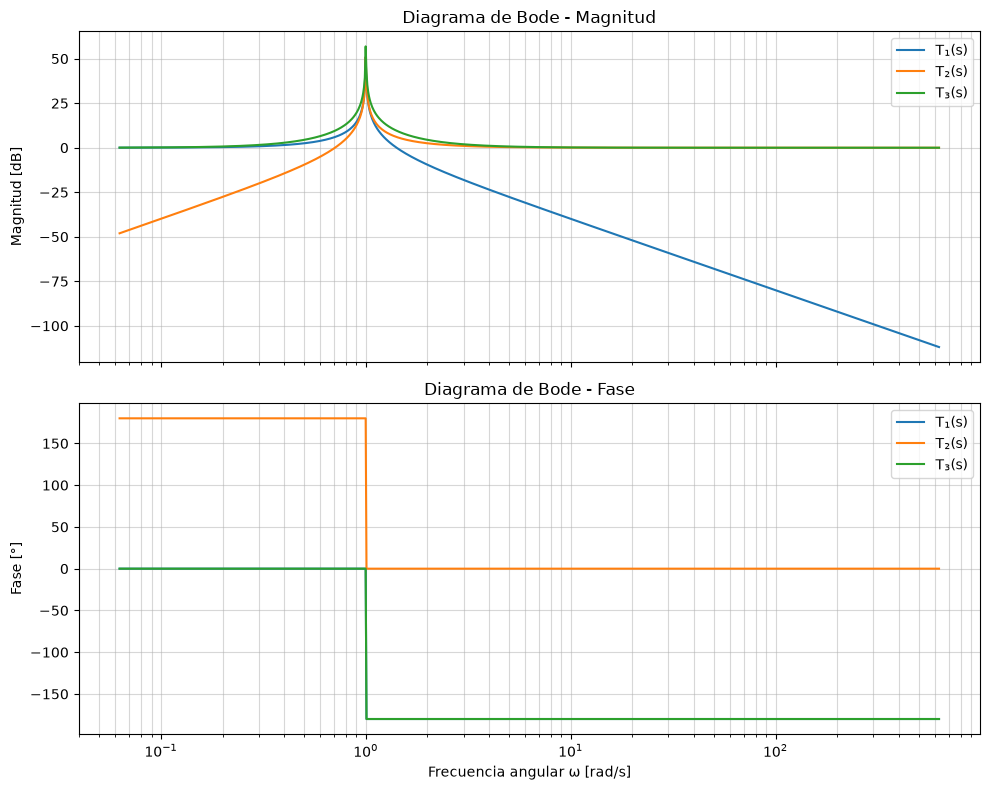

In [2]:
L = 1
C = 1

num1 = np.array([0,0,1])
num2 = np.array([L*C,0,0])
num3 = np.array([-L*C,0,1])

den = np.array([L*C,0,1])

T1 = TransferFunction(num1, den)
T2 = TransferFunction(num2, den)
T3 = TransferFunction(num3, den)


f = np.logspace(-2, 2, 1000)

w = 2*np.pi*f

# Bode
w, mag1, phase1 = sig.bode(T1, w)
w, mag2, phase2 = sig.bode(T2, w)
w, mag3, phase3 = sig.bode(T3, w)

fig, (ax_mag, ax_phase) = plt.subplots(
    2, 1, figsize=(10, 8), sharex=True
)

# Magnitud
ax_mag.semilogx(w, mag1, label='T₁(s)')
ax_mag.semilogx(w, mag2, label='T₂(s)')
ax_mag.semilogx(w, mag3, label='T₃(s)')

ax_mag.set_title('Diagrama de Bode - Magnitud')
ax_mag.set_ylabel('Magnitud [dB]')
ax_mag.grid(True, which='both', ls='-', alpha=0.5)
ax_mag.legend()

# Fase
ax_phase.semilogx(w, phase1, label='T₁(s)')
ax_phase.semilogx(w, phase2, label='T₂(s)')
ax_phase.semilogx(w, phase3, label='T₃(s)')

ax_phase.set_title('Diagrama de Bode - Fase')
ax_phase.set_ylabel('Fase [°]')
ax_phase.set_xlabel('Frecuencia angular ω [rad/s]')
ax_phase.grid(True, which='both', ls='-', alpha=0.5)
ax_phase.legend()

plt.tight_layout()
plt.show()

Con los gráficos ya nos camos cuenta cual es el par de transferencia que cumple que $|T_a + T_b| = 1$. Estas son $T_1$ y $T_2$.

Se igual manera lo compruebo analíticamente.

<center><img src="./src/img8_TS6.png"  width="800"></center>

### Punto 3
#### Subpunto a
Hallo los parámetros $Y$ del transistor para las configuraciones *sorce común* y *drain común* aterrizando el borne correspondiente para cada caso.

<center><img src="./src/img9_TS6.png"  width="800"></center>

#### Subpunto 

Obtengo la matriz de parámetros $ABCD$ en configuración source común en función de los parámetros $Y$ hallados.

<center><img src="./src/img10_TS6.png"  width="800"></center>

### Conclusión
El trabajo verificó en la práctica las propiedades teóricas de la *MAI* (suma de filas/columnas nula, determinante nulo, igualdad de cofactores de primer orden) tanto para la *red T* como para el modelo lineal del *BS170*, y mostró que las transferencias de tensión requieren cofactores de segundo orden, ya que los de primer orden resultan todos iguales entre sí y no aportan información. En la red T se obtuvieron correctamente las tres transferencias pedidas, verificándose además que $V_{23}/V_{13} + V_{21}/V_{31} = 1$ de forma exacta; y para el MOS, aterrizar cada borne sobre la *MAI* reprodujo los parámetros $Y$ de source y drain común, cuya posterior conversión a $ABCD$ arrojó resultados coherentes con el comportamiento físico esperado del transistor.